In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
train_txn = pd.read_csv('../data/raw/train_transaction.csv')
train_id  = pd.read_csv('../data/raw/train_identity.csv')

print(f"Transaction data: {train_txn.shape}")
print(f"Identity data:    {train_id.shape}")

Transaction data: (590540, 394)
Identity data:    (144233, 41)


In [3]:
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
df.head(3)

Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
## fraud count 
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(f"\nFraud rate: {fraud_pct[1]:.2f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


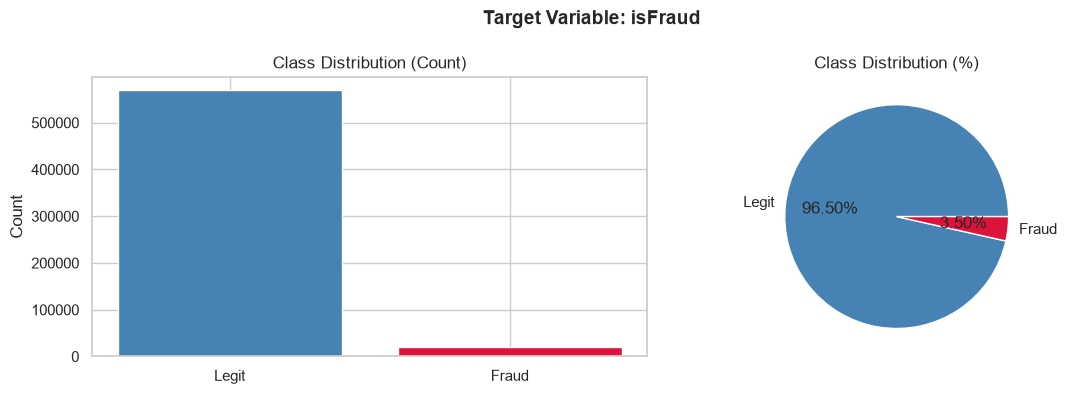

In [10]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legit', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')

axes[1].pie(fraud_counts.values, labels=['Legit', 'Fraud'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'])
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: isFraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Columns with missing values: 414 / 434
       Missing Count  Missing %
id_24         585793  99.196159
id_25         585408  99.130965
id_07         585385  99.127070
id_08         585385  99.127070
id_21         585381  99.126393
id_26         585377  99.125715
id_23         585371  99.124699
id_22         585371  99.124699
id_27         585371  99.124699
dist2         552913  93.628374
D7            551623  93.409930
id_18         545427  92.360721
D13           528588  89.509263
D14           528353  89.469469
D12           525823  89.041047
id_04         524216  88.768923
id_03         524216  88.768923
D6            517353  87.606767
id_33         517251  87.589494
id_10         515614  87.312290


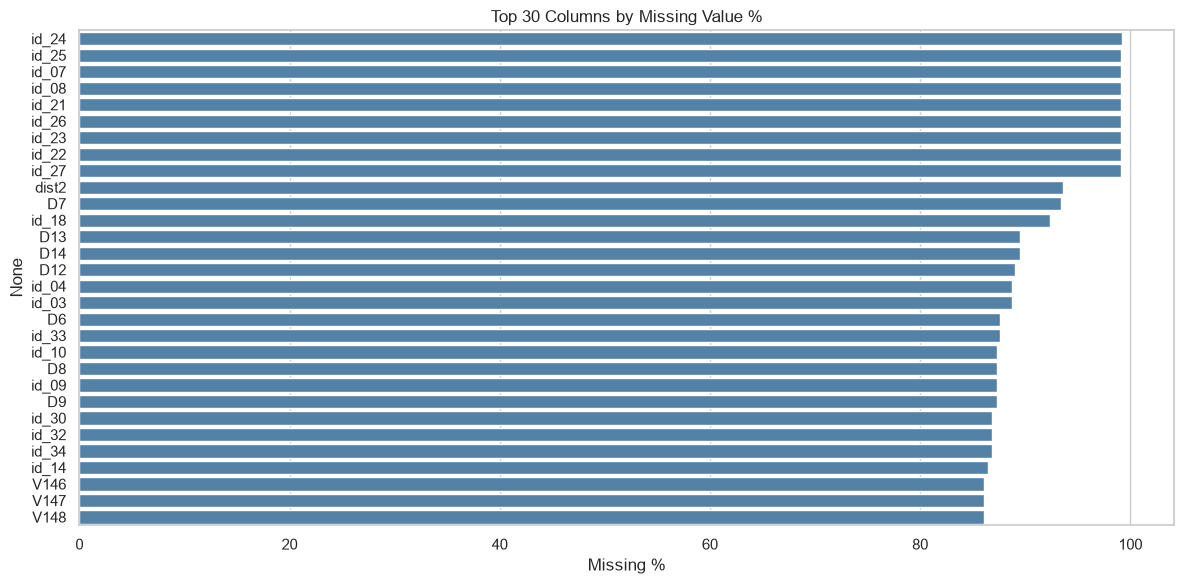

In [11]:
## missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {df.shape[1]}")
print(missing_df.head(20))

# Plot top 30 columns with most missing
top_missing = missing_df.head(30)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_missing['Missing %'], y=top_missing.index, color='steelblue')
plt.title('Top 30 Columns by Missing Value %')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

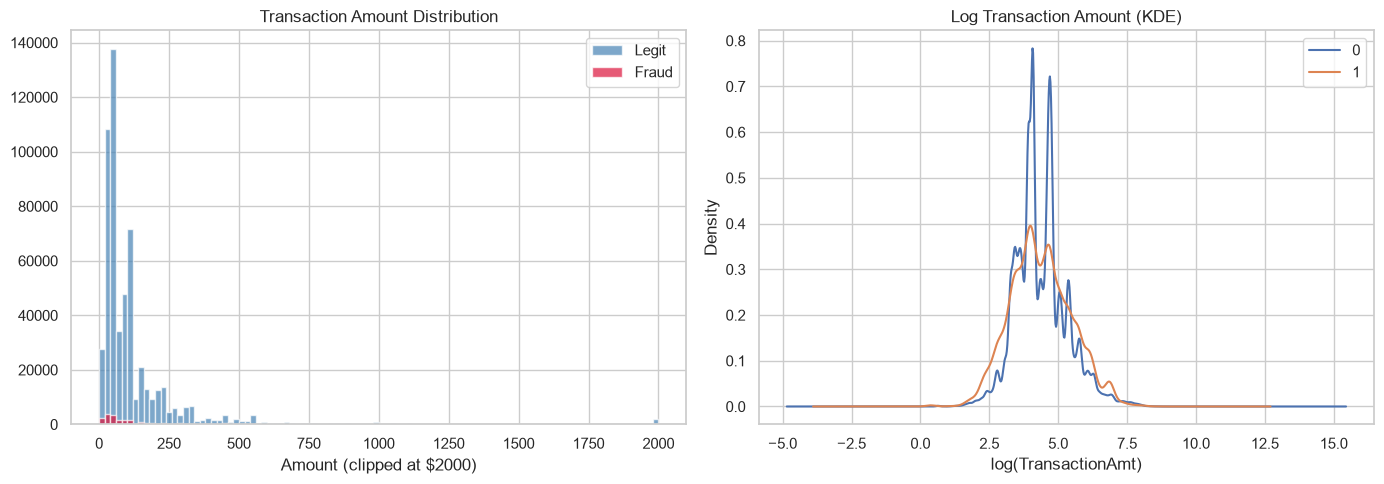

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [12]:

## transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=2000).hist(
    bins=100, ax=axes[0], color='steelblue', alpha=0.7, label='Legit')
df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=2000).hist(
    bins=100, ax=axes[0], color='crimson', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (clipped at $2000)')
axes[0].legend()

# Log scale
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
df.groupby('isFraud')['TransactionAmt_log'].plot(
    kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Log Transaction Amount (KDE)')
axes[1].set_xlabel('log(TransactionAmt)')

plt.tight_layout()
plt.show()

print(df.groupby('isFraud')['TransactionAmt'].describe())

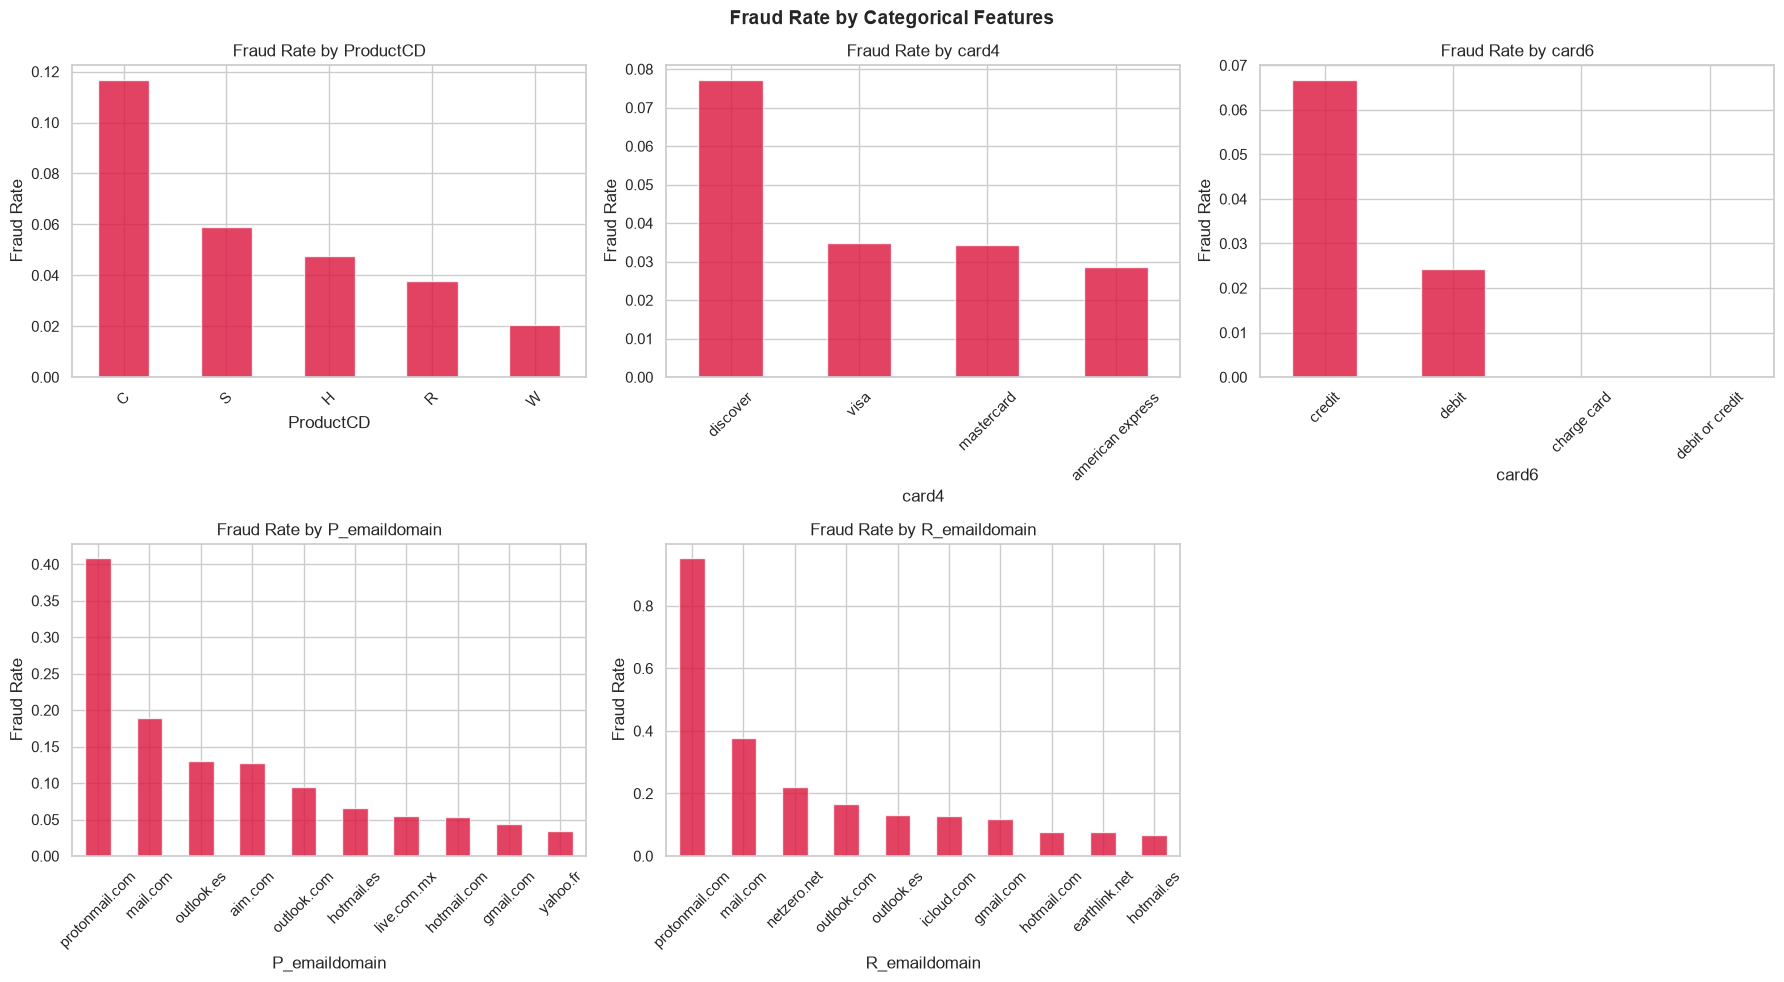

In [13]:
## categorical features distribution
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False).head(10)
    fraud_rate.plot(kind='bar', ax=axes[i], color='crimson', alpha=0.8)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Key EDA Insights

1. **Severe class imbalance** — only ~3.5% of transactions are fraud.
   This means accuracy is a misleading metric; we'll use PR-AUC and F1.
   We'll handle this with SMOTE + class_weight in modeling.

2. **High missing values** — many V-columns (anonymized features) have
   50-99% missing. Strategy: drop >90% missing, impute the rest.

3. **Fraud transactions skew higher in amount** — log distribution shows
   fraud peaks at higher values, making TransactionAmt a useful feature.

4. **ProductCD 'C' and 'H'** have higher fraud rates than others.

5. **Email domains matter** — certain domains correlate strongly with fraud.

6. **Next step** — feature engineering: encode categoricals, handle missing
   values, create ratio features (amt/mean_amt per card).